# Taller Practico: Sistema Difuso Sugeno
**Catedra de Inteligencia Artificial - Ingenieria**  
*CUADERNO DE TRABAJO (ESTUDIANTES)*

---

### Objetivos del Taller
1. **Comprender la particion del espacio** mediante clustering (K-Means 1D) para inducir reglas difusas automaticamente.
2. **Implementar la Fuzzificacion:** Programar la funcion de pertenencia Gaussiana $\mu_i(x)$ (**TODO 1**).
3. **Modelar los Consecuentes:** Ajustar funciones locales de primer orden (rectas $z_i(x) = p_i x + r_i$) (**TODO 2**).
4. **Programar la Inferencia Sugeno:** Calcular la salida global mediante promedio ponderado (**TODO 3**).
5. **Analizar la Generalizacion:** Evaluar el comportamiento en **interpolacion** vs **extrapolacion**.

---
### Dinamica de la Clase
El codigo base y la infraestructura grafica ya estan provistos. Tu tarea consiste en completar los bloques marcados como `TODO 1`, `TODO 2` y `TODO 3`. Cada seccion cuenta con una celda de **autoevaluacion** para validar tus resultados antes de avanzar.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Estilo visual limpio y legible
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

## 0. Generacion del Dataset Sintetico
Generamos $N = 150$ muestras de la funcion no lineal $y = \sin(x) + \epsilon$, con ruido gaussiano $\epsilon \sim \mathcal{N}(0, 0.12^2)$ en el intervalo $x \in [-3, 3]$.

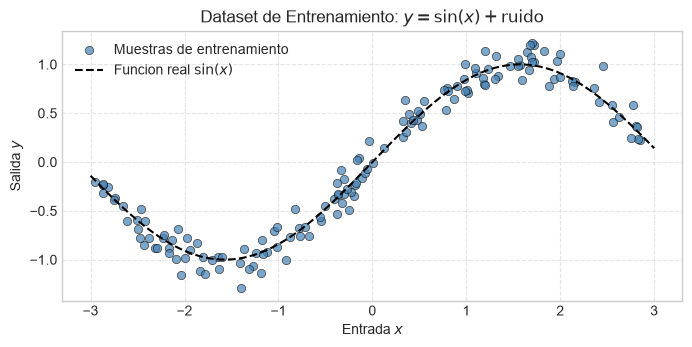

In [2]:
rng = np.random.default_rng(42)
N = 150
x = rng.uniform(-3, 3, size=N)
ruido = rng.normal(0, 0.12, size=N)
y = np.sin(x) + ruido

# Vista preliminar de los datos
plt.figure(figsize=(8, 3.5))
plt.scatter(x, y, color="steelblue", alpha=0.7, edgecolors="k", linewidth=0.5, label="Muestras de entrenamiento")
plt.plot(np.linspace(-3, 3, 200), np.sin(np.linspace(-3, 3, 200)), color="black", linestyle="--", label=r"Funcion real $\sin(x)$")
plt.title(r"Dataset de Entrenamiento: $y = \sin(x) + \mathrm{ruido}$")
plt.xlabel("Entrada $x$")
plt.ylabel("Salida $y$")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

## 1. Deteccion de Reglas mediante K-Means 1D
Cada regla en nuestro sistema difuso tendra la estructura:
$$\textbf{Regla } i: \text{SI } x \text{ esta cerca de } c_i \text{ ENTONCES } z_i(x) = p_i x + r_i$$

Para ubicar los centros $c_i$ de manera guiada por los datos, ejecutamos **K-Means** con $K=3$ clusters sobre el eje de entrada $x$.
Definimos el ancho $\sigma$ de las campanas para asegurar una transicion suave entre reglas adyacentes:
$$\sigma = \frac{\max(x) - \min(x)}{\sqrt{8}}$$

In [4]:
# ==========================================================================
# 1. Particion del Espacio de Entrada con K-Means
# ==========================================================================

n_reglas = 3

# Pista: Configura el algoritmo de agrupamiento no supervisado (KMeans) de scikit-learn.
# km = KMeans(n_clusters=..., random_state=42)
km = KMeans(n_clusters=3, random_state=42)
etiquetas = km.fit_predict(x.reshape(-1, 1))

# Extraer los centros calculados por K-Means
centros = km.cluster_centers_.flatten() if km is not None else np.array([0.0, 0.0, 0.0])

idx_orden = np.argsort(centros)
centros = centros[idx_orden]
mapa = {viejo: nuevo for nuevo, viejo in enumerate(idx_orden)}
etiquetas = np.array([mapa[e] for e in etiquetas]) if etiquetas is not None else None

# Revisa la ecuacion para sigma dada arriba en funcion del rango total de x.
sigma = (x.max() - x.min()) / np.sqrt(8)

colores = ["#1f77b4", "#ff7f0e", "#2ca02c"]

print("Centros identificados (c_i):", np.round(centros, 3))
if sigma is not None:
    print(f"Ancho sigma calculado: {sigma:.3f}")

Centros identificados (c_i): [-2.052 -0.151  1.745]
Ancho sigma calculado: 2.054


In [ ]:
# TEST AUTOMATICO - PASO 1 (K-Means y Parametros)
assert n_reglas == 3, "[ERROR] n_reglas debe ser igual a 3."
assert isinstance(km, KMeans), "[ERROR] km debe ser una instancia de KMeans."
assert etiquetas is not None and len(etiquetas) == len(x), "[ERROR] etiquetas debe contener las asignaciones de cluster para cada dato."
assert len(centros) == 3, "[ERROR] Se esperaban 3 centros."
assert sigma is not None, "[ERROR] Debes calcular sigma."
assert np.isclose(sigma, (x.max() - x.min()) / np.sqrt(8)), "[ERROR] Revisa el calculo de sigma: (x.max() - x.min()) / np.sqrt(8)"
print("[OK] Paso 1 completado con exito: K-Means ajustado y sigma calculado.")

## 2. [TODO 1] Fuzzificacion: Funcion de Pertenencia Gaussiana

### Ecuacion
La funcion de pertenencia $\mu_i(x)$ asigna un grado entre $0$ y $1$ segun que tan cerca esta la entrada $x$ del centro $c_i$:
$$\mu_i(x) = \exp\left( -\frac{(x - c_i)^2}{2 \sigma^2} \right)$$

**Propiedades:**
- Cuando $x = c_i \implies \mu_i(x) = 1.0$.
- Cuando $|x - c_i| \to \infty \implies \mu_i(x) \to 0.0$.

In [5]:
def gaussiana(x_val, c, sig):
    """
    TODO 1: Implementar la funcion de pertenencia gaussiana.
    
    Parametros:
      x_val: valor escalar o array de numpy con las entradas x.
      c: centroide de la campana (escalar).
      sig: ancho / desviacion estandar sigma (escalar).
      
    Retorna:
      Grado de pertenencia mu en el intervalo (0, 1].
    """
    return np.exp(-((x_val - c) ** 2) / (2.0 * sig**2))

In [6]:
# TEST AUTOMATICO - TODO 1
val_c = gaussiana(0.0, 0.0, 1.0)
val_alejado = gaussiana(2.0, 0.0, 1.0)

assert val_c is not None, "[ERROR] La funcion retorno None. Completa la implementacion."
assert np.isclose(val_c, 1.0), f"[ERROR] En el centro x=c debe dar 1.0, pero dio {val_c}"
assert np.isclose(val_alejado, np.exp(-2.0)), f"[ERROR] Calculo incorrecto para x=2, c=0, sig=1. Revisa los parentesis."
print("[OK] Felicitaciones: TODO 1 aprobado con exito.")

[OK] Felicitaciones: TODO 1 aprobado con exito.


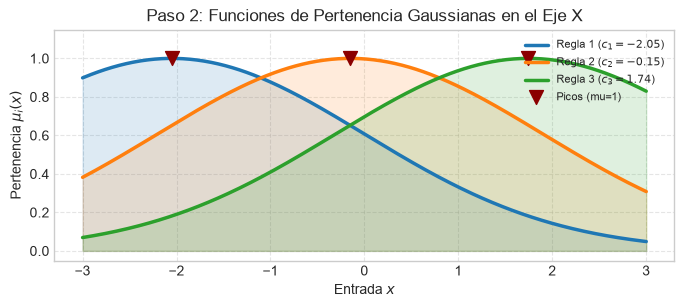

In [7]:
def calcular_pesos(x_in):
    """Calcula el vector de pertenencias [mu_1(x), mu_2(x), mu_3(x)]."""
    return np.array([gaussiana(x_in, c, sigma) for c in centros])

# Visualizacion de las 3 campanas gaussianas
x_grid = np.linspace(-3.0, 3.0, 400)
plt.figure(figsize=(8, 3))
for i in range(3):
    mu = gaussiana(x_grid, centros[i], sigma)
    plt.plot(x_grid, mu, color=colores[i], linewidth=2.5, label=rf"Regla {i+1} ($c_{i+1}={centros[i]:.2f}$)")
    plt.fill_between(x_grid, mu, alpha=0.15, color=colores[i])

plt.scatter(centros, np.ones_like(centros), color="darkred", marker="v", s=100, zorder=5, label="Picos (mu=1)")
plt.title(r"Paso 2: Funciones de Pertenencia Gaussianas en el Eje X")
plt.xlabel("Entrada $x$")
plt.ylabel(r"Pertenencia $\mu_i(x)$")
plt.ylim(-0.05, 1.15)
plt.legend(loc="upper right", fontsize=8)
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

## 3. [TODO 2] Consecuentes de Sugeno Orden 1 (Modelos Locales)

### Ecuacion
En Sugeno Orden 1, cada regla $i$ modela localmente la salida con una recta:
$$z_i(x) = p_i \cdot x + r_i$$

Para determinar la pendiente $p_i$ y la ordenada $r_i$ de cada regla, realizamos una regresion lineal sobre las muestras que cayeron en ese cluster.


In [9]:
rectas = []

for i in range(3):
    mask = (etiquetas == i)  # Mascara booleana para seleccionar las muestras del cluster i
    x_c = x[mask]
    y_c = y[mask]

    recta = np.polynomial.Polynomial.fit(x_c, y_c, deg=1)

    [ordenada, pendiente] = recta.convert().coef

    rectas.append([pendiente, ordenada])

rectas = np.array(rectas)

In [10]:
# TEST AUTOMATICO - TODO 2
assert rectas[0][0] is not None, "[ERROR] Debes calcular los coeficientes de las rectas."
assert rectas.shape == (3, 2), f"[ERROR] La matriz 'rectas' debe ser de forma (3, 2), pero tiene {rectas.shape}"
print("[OK] Felicitaciones: TODO 2 aprobado con exito.\n")
print("Rectas locales obtenidas:")
for i, (p, r) in enumerate(rectas):
    print(f"  * Regla {i+1}: z_{i+1}(x) = {p:+.3f}*x {r:+.3f}")

[OK] Felicitaciones: TODO 2 aprobado con exito.

Rectas locales obtenidas:
  * Regla 1: z_1(x) = -0.416*x -1.650
  * Regla 2: z_2(x) = +0.906*x +0.016
  * Regla 3: z_3(x) = -0.227*x +1.225


## 4. [TODO 3] Inferencia Sugeno (Defuzzificacion por Promedio Ponderado)

### Ecuacion
Para cualquier punto de entrada $x$, la prediccion final $\hat{y}(x)$ combina las salidas de todas las reglas ponderadas por su grado de pertenencia:
$$\hat{y}(x) = \frac{\sum_{i=1}^K w_i(x) \cdot z_i(x)}{\sum_{i=1}^K w_i(x)}$$

donde:
- $w_i(x) = \mu_i(x)$ (pesos calculados con `calcular_pesos(x_in)`).
- $z_i(x) = p_i x + r_i$ (salida de la recta local $i$).


In [11]:
def inferencia_orden1(x_in):
    """
    TODO 3: Implementar la inferencia Takagi-Sugeno Orden 1.
    
    Parametros:
      x_in: array 1D con las entradas a evaluar.
      
    Retorna:
      y_pred: array 1D con las predicciones ponderadas del modelo.
    """

    

    w = calcular_pesos(x_in)
    w = np.where(w < 1e-8, np.mean(y), w)

    # Consecuentes de cada regla: z_i(x) = p_i*x + r_i
    z = np.array([p * x_in + r for p, r in rectas])

    # Promedio ponderado para cada muestra
    numerador = np.sum(w * z, axis=0)
    denominador = np.sum(w, axis=0)

    return numerador / denominador

In [12]:
# TEST AUTOMATICO - TODO 3
y_pred_train = inferencia_orden1(x)
assert y_pred_train is not None, "[ERROR] La funcion inferencia_orden1 retorno None."
mse_train = np.mean((y - y_pred_train)**2)
assert mse_train < 0.15, f"[ERROR] El MSE en entrenamiento es {mse_train:.4f} (deberia ser < 0.15). Revisa la formula del promedio ponderado."
print("[OK] Excelente: TODO 3 aprobado con exito!")
print(f"MSE en entrenamiento: {mse_train:.4f}")

[OK] Excelente: TODO 3 aprobado con exito!
MSE en entrenamiento: 0.1012


## 5. El Grafico Resumen: Visualizacion Completa del Flujo en 4 Paneles
Ahora que completaste las funciones fundamentales, ejecuta la celda inferior para ver como interactuan los 4 componentes:
1. **Clustering y Centros en X**
2. **Fuzzificacion (Campanas Gaussianas)**
3. **Modelos Locales y Curva Agregada**
4. **Generalizacion (Interpolacion vs Extrapolacion)**

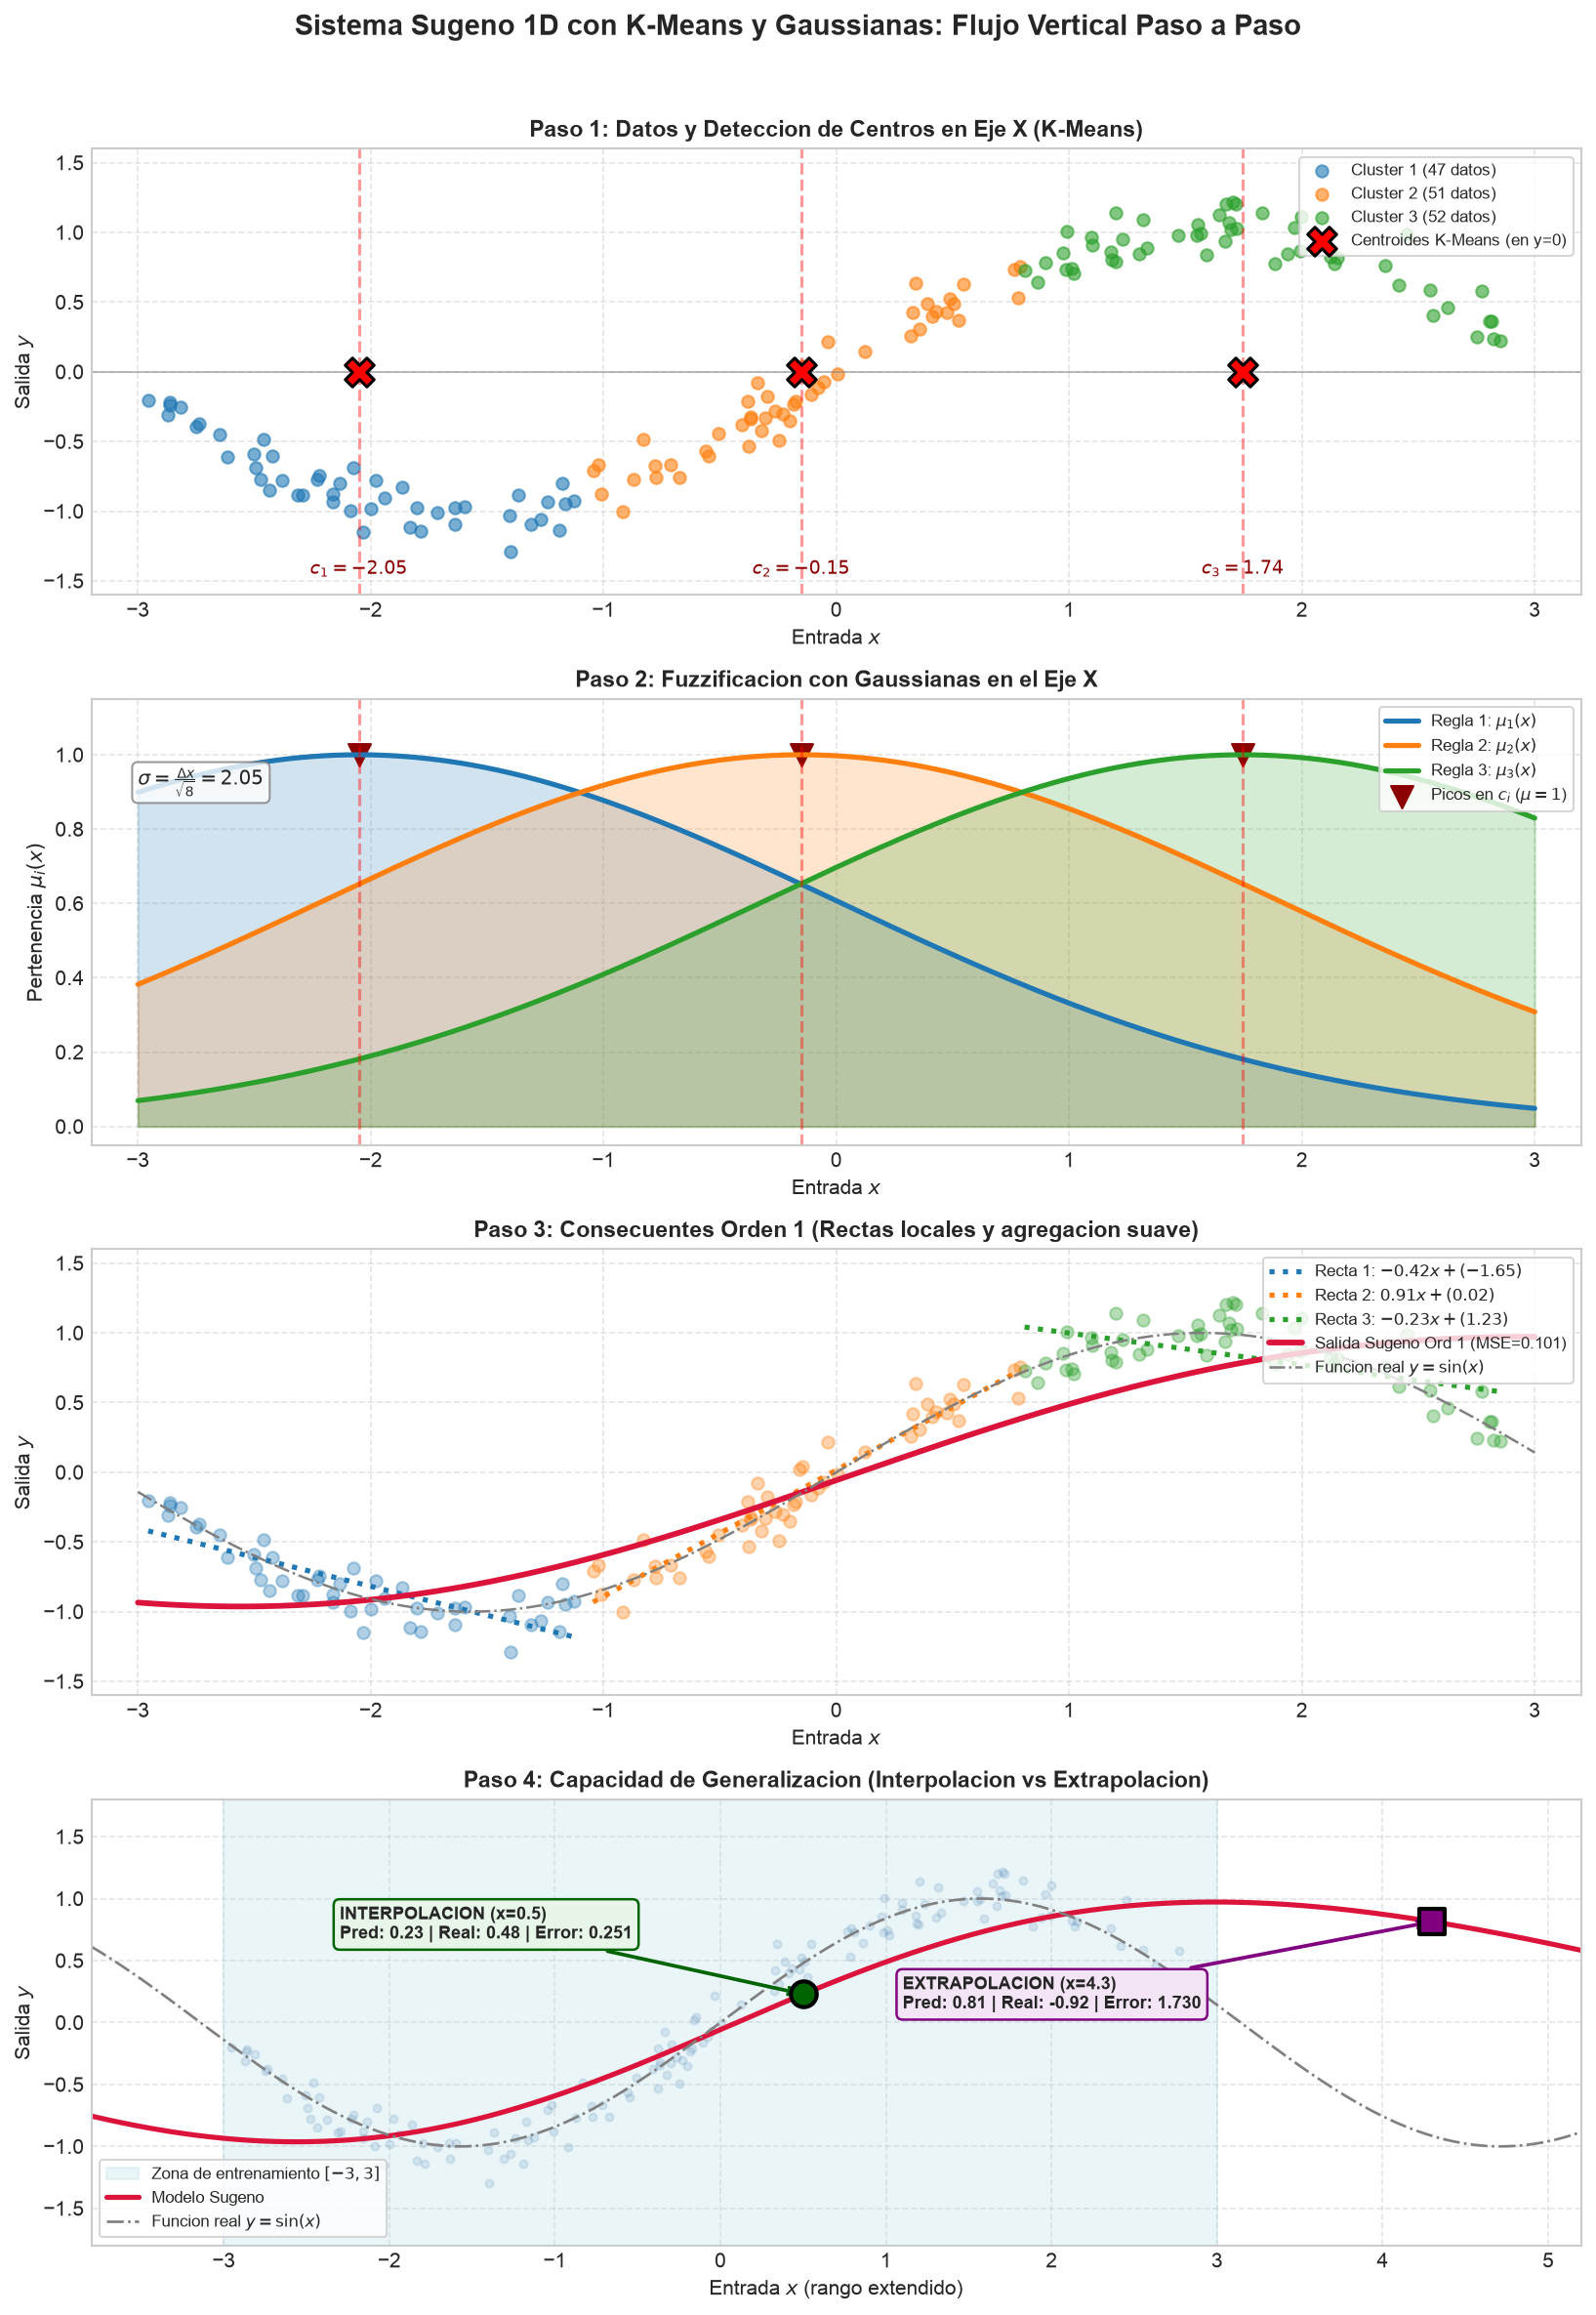

In [13]:
fig, axes = plt.subplots(4, 1, figsize=(11, 16), dpi=150)
fig.suptitle("Sistema Sugeno 1D con K-Means y Gaussianas: Flujo Vertical Paso a Paso", 
             fontsize=14, fontweight='bold', y=0.995)

# ---------------------------------------------------------------------------
# PANEL 1: Dataset y Centros K-Means
# ---------------------------------------------------------------------------
ax1 = axes[0]
for i in range(3):
    mask = (etiquetas == i)
    ax1.scatter(x[mask], y[mask], color=colores[i], alpha=0.6, label=f"Cluster {i+1} ({np.sum(mask)} datos)")

ax1.scatter(centros, np.zeros_like(centros), marker="X", s=200, color="red", 
            edgecolors="black", linewidth=1.5, zorder=6, label="Centroides K-Means (en y=0)")

for i, c in enumerate(centros):
    ax1.axvline(c, color="red", linestyle="--", alpha=0.4)
    ax1.annotate(rf"$c_{i+1} = {c:.2f}$", xy=(c, -1.25), xytext=(c, -1.45),
                 ha='center', fontsize=9, fontweight='bold', color='darkred')

ax1.axhline(0, color='gray', linestyle='-', linewidth=0.8, alpha=0.6)
ax1.set_title("Paso 1: Datos y Deteccion de Centros en Eje X (K-Means)", fontsize=11, fontweight='bold')
ax1.set_xlabel("Entrada $x$")
ax1.set_ylabel("Salida $y$")
ax1.set_xlim(-3.2, 3.2)
ax1.set_ylim(-1.6, 1.6)
ax1.legend(loc="upper right", frameon=True, fontsize=8)
ax1.grid(True, linestyle="--", alpha=0.5)

# ---------------------------------------------------------------------------
# PANEL 2: Funciones de Pertenencia
# ---------------------------------------------------------------------------
ax2 = axes[1]
for i in range(3):
    mu = gaussiana(x_grid, centros[i], sigma)
    ax2.plot(x_grid, mu, color=colores[i], linewidth=2.5, label=rf"Regla {i+1}: $\mu_{i+1}(x)$")
    ax2.fill_between(x_grid, mu, alpha=0.2, color=colores[i])

ax2.scatter(centros, np.ones_like(centros), marker="v", s=120, color="darkred", label=r"Picos en $c_i$ ($\mu=1$)")
for c in centros:
    ax2.axvline(c, color="red", linestyle="--", alpha=0.4)

ax2.set_title(r"Paso 2: Fuzzificacion con Gaussianas en el Eje X", fontsize=11, fontweight='bold')
ax2.set_xlabel("Entrada $x$")
ax2.set_ylabel(r"Pertenencia $\mu_i(x)$")
ax2.set_xlim(-3.2, 3.2)
ax2.set_ylim(-0.05, 1.15)
ax2.annotate(rf"$\sigma = \frac{{\Delta x}}{{\sqrt{{8}}}} = {sigma:.2f}$", xy=(-3.0, 0.92), 
             bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8), fontsize=9.5)
ax2.legend(loc="upper right", frameon=True, fontsize=8)
ax2.grid(True, linestyle="--", alpha=0.5)

# ---------------------------------------------------------------------------
# PANEL 3: Rectas Locales y Curva Agregada
# ---------------------------------------------------------------------------
ax3 = axes[2]
for i in range(3):
    mask = (etiquetas == i)
    ax3.scatter(x[mask], y[mask], color=colores[i], alpha=0.35)

for i in range(3):
    mask = (etiquetas == i)
    xmin_c, xmax_c = x[mask].min(), x[mask].max()
    xg_local = np.linspace(xmin_c, xmax_c, 50)
    p, r = rectas[i]
    ax3.plot(xg_local, p * xg_local + r, color=colores[i], linewidth=2.5,
             linestyle=':', label=rf"Recta {i+1}: ${p:.2f}x + ({r:.2f})$")

y_hat_grid = inferencia_orden1(x_grid)
ax3.plot(x_grid, y_hat_grid, color="crimson", linewidth=2.8, label=f"Salida Sugeno Ord 1 (MSE={mse_train:.3f})")
ax3.plot(x_grid, np.sin(x_grid), color="gray", linewidth=1.2, linestyle="-.", label=r"Funcion real $y = \sin(x)$")

ax3.set_title("Paso 3: Consecuentes Orden 1 (Rectas locales y agregacion suave)", fontsize=11, fontweight='bold')
ax3.set_xlabel("Entrada $x$")
ax3.set_ylabel("Salida $y$")
ax3.set_xlim(-3.2, 3.2)
ax3.set_ylim(-1.6, 1.6)
ax3.legend(loc="upper right", frameon=True, fontsize=8)
ax3.grid(True, linestyle="--", alpha=0.5)

# ---------------------------------------------------------------------------
# PANEL 4: Generalizacion (Interpolacion vs Extrapolacion)
# ---------------------------------------------------------------------------
ax4 = axes[3]
x_ext = np.linspace(-3.8, 5.2, 500)
y_ext_sugeno = inferencia_orden1(x_ext)
y_ext_real = np.sin(x_ext)

ax4.axvspan(-3.0, 3.0, color='lightblue', alpha=0.25, label="Zona de entrenamiento $[-3, 3]$")
ax4.plot(x_ext, y_ext_sugeno, color="crimson", linewidth=2.5, label="Modelo Sugeno")
ax4.plot(x_ext, y_ext_real, color="gray", linestyle="-.", linewidth=1.3, label=r"Funcion real $y = \sin(x)$")
ax4.scatter(x, y, color="steelblue", alpha=0.15, s=15)

# Punto 1: Interpolacion
x_interp = 0.5
y_interp_pred = inferencia_orden1(np.array([x_interp]))[0]
y_interp_real = np.sin(x_interp)
ax4.scatter([x_interp], [y_interp_pred], color="darkgreen", s=160, marker="o", edgecolors="black", linewidth=2, zorder=8)
ax4.annotate(
    f"INTERPOLACION (x={x_interp})\n"
    rf"Pred: {y_interp_pred:.2f} | Real: {y_interp_real:.2f} | Error: {abs(y_interp_pred - y_interp_real):.3f}",
    xy=(x_interp, y_interp_pred), xytext=(x_interp - 2.8, y_interp_pred + 0.45),
    arrowprops=dict(arrowstyle="->", color="darkgreen", lw=1.8),
    bbox=dict(boxstyle="round,pad=0.35", fc="#e8f5e9", ec="darkgreen", lw=1.2),
    fontsize=8.5, fontweight='bold'
)

# Punto 2: Extrapolacion
x_extrap = 4.3
y_extrap_pred = inferencia_orden1(np.array([x_extrap]))[0]
y_extrap_real = np.sin(x_extrap)
ax4.scatter([x_extrap], [y_extrap_pred], color="purple", s=160, marker="s", edgecolors="black", linewidth=2, zorder=8)
ax4.annotate(
    f"EXTRAPOLACION (x={x_extrap})\n"
    rf"Pred: {y_extrap_pred:.2f} | Real: {y_extrap_real:.2f} | Error: {abs(y_extrap_pred - y_extrap_real):.3f}",
    xy=(x_extrap, y_extrap_pred), xytext=(x_extrap - 3.2, y_extrap_pred - 0.7),
    arrowprops=dict(arrowstyle="->", color="purple", lw=1.8),
    bbox=dict(boxstyle="round,pad=0.35", fc="#f3e5f5", ec="purple", lw=1.2),
    fontsize=8.5, fontweight='bold'
)

ax4.set_title("Paso 4: Capacidad de Generalizacion (Interpolacion vs Extrapolacion)", fontsize=11, fontweight='bold')
ax4.set_xlabel("Entrada $x$ (rango extendido)")
ax4.set_ylabel("Salida $y$")
ax4.set_xlim(-3.8, 5.2)
ax4.set_ylim(-1.8, 1.8)
ax4.legend(loc="lower left", frameon=True, fontsize=8)
ax4.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout(rect=[0, 0.01, 1, 0.98])
plt.show()